<a href="https://colab.research.google.com/github/shiv-coder/AIDI1002W2026/blob/main/module9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print(df.info())
print(df.describe())


Saving pca_lda_dataset.csv to pca_lda_dataset.csv
   HoursStudied  Attendance  AssignmentsCompleted  PreviousScore  \
0             5          80                     8             70   
1             3          60                     5             50   
2             8          90                     9             85   
3             2          50                     4             40   
4             6          85                     7             75   

   Participation  ExamScore  Passed  
0              9         75       1  
1              6         55       0  
2             10         88       1  
3              4         45       0  
4              8         80       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   HoursStudied          20 non-null     int64
 1   Attendance            20 non-null     int64
 2   Assignment

In [ ]:
from sklearn.preprocessing import StandardScaler

features = df[["HoursStudied", "Attendance", "AssignmentsCompleted",
              "PreviousScore", "Participation", "ExamScore"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print(X_scaled)

[[ 0.04617571  0.43130763  0.70530981  0.2774207   0.96131896  0.35417002]
 [-0.87733848 -0.85617784 -0.80606835 -0.92875627 -0.44548927 -0.85666765]
 [ 1.431447    1.07505037  1.20910253  1.18205343  1.43025504  1.1412145 ]
 [-1.33909558 -1.49992057 -1.30986108 -1.53184475 -1.38336143 -1.46208649]
 [ 0.50793281  0.753179    0.20151709  0.57896494  0.49238288  0.65687944]
 [-0.41558139 -0.53430647 -0.30227563 -0.62721202 -0.91442535 -0.55395823]
 [ 0.9696899   0.94630182  0.70530981  0.88050919  0.96131896  0.95958885]
 [-0.87733848 -1.1780492  -0.80606835 -1.23030051 -0.91442535 -1.15937707]
 [ 1.8932041   1.39692173  1.71289525  1.48359767  1.43025504  1.38338204]
 [-1.80085268 -2.1436633  -1.8136538  -1.83338899 -1.85229751 -1.88587967]
 [ 0.50793281  0.56005618  0.20151709  0.3980384   0.49238288  0.53579567]
 [ 0.04617571  0.30255909 -0.30227563  0.15680301  0.0234468   0.0514606 ]
 [-0.41558139 -0.2124351  -0.80606835 -0.32566778 -0.44548927 -0.43287447]
 [ 0.9696899   0.94630182

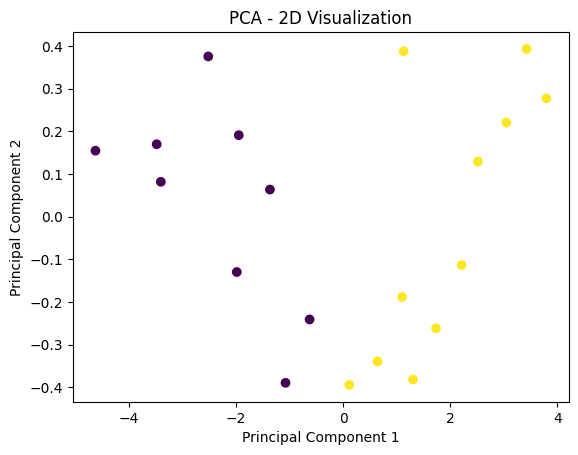

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df["Passed"], cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")
plt.show()

In [ ]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=["PC1","PC2"]
)

print(loadings)

     HoursStudied  Attendance  AssignmentsCompleted  PreviousScore  \
PC1      0.408131    0.408630              0.404899       0.410288   
PC2      0.150348   -0.483555              0.636860      -0.358156   

     Participation  ExamScore  
PC1       0.405988   0.411514  
PC2       0.355252  -0.288962  


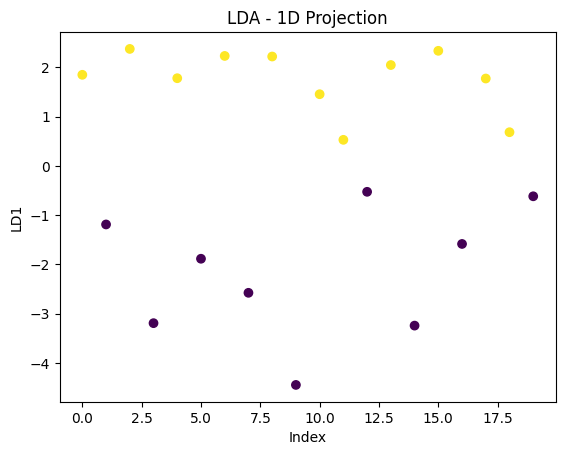

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

X = df[["HoursStudied", "Attendance", "AssignmentsCompleted",
       "PreviousScore", "Participation", "ExamScore"]]
y = df["Passed"]

lda = LDA(n_components=1)
lda_result = lda.fit_transform(X, y)

# Scatter plot (1D can be visualized with index or small jitter)
plt.scatter(range(len(lda_result)), lda_result, c=y, cmap='viridis')
plt.xlabel("Index")
plt.ylabel("LD1")
plt.title("LDA - 1D Projection")
plt.show()